# Example usage of *libinsitu*

This Notebook demonstrates the basic usage of [libinsitu](https://libinsitu.readthedocs.io/en/latest/), fetching and showing solar irradiance data of a well-formed NetCDF file.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

from libinsitu import netcdf_to_dataframe, visual_qc
from datetime import datetime
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Fetch a subset of data over the network (OpenDAP)

The function **netcdf_to_dataframe** loads data from a local or remote (over OpenDAP) NetCDF file and format it to a **pandas Dataframe**, ready to be used.

This function allows to only fetch a subset of variables and time range. Only the requested data is loaded from disk or the network, making it fast.

The full API [is documented here](https://libinsitu.readthedocs.io/en/latest/api.html#libinsitu.common.netcdf_to_dataframe)

In the example below, we get data from the network [NREL MIDC from our Thredds server](http://tds.webservice-energy.org/thredds/catalog/nrelmidc-stations/catalog.html)

The available data on our server is [documented here](https://libinsitu.readthedocs.io/en/latest/data.html).

In [4]:
# Fetch one year of data, for 3 variables
df = netcdf_to_dataframe(
    "http://tds.webservice-energy.org/thredds/dodsC/nrelmidc-stations/NREL_MIDC-BMS.nc",
    start_time=datetime(2020, 1, 1),
    end_time=datetime(2021, 3, 1),
    vars=["GHI", "BNI", "DHI"])

## Metadata

The full metadata is kept in property `attrs` of the Dataframe :

In [5]:
# Shoow first 10 values of meta-data
dict(list(df.attrs.items())[0:10])

{'id': 'NREL_MIDC-BMS',
 'title': 'Timeseries of Measurement and Instrumentation Data Center (MIDC) (NREL_MIDC). Station : NREL Solar Radiation Research Laboratory - Baseline Measurement System',
 'summary': 'Archive of solar radiation networks worldwide provided by the Webservice-Energy initiative supported by MINES Paris PSL. Files are provided as NetCDF file format with the support of a Thredds Data Server.',
 'keywords': 'meteorology, station, time, Earth Science > Atmosphere > Atmospheric Radiation > Incoming Solar Radiation, Earth Science > Atmosphere > Atmospheric Temperature > Surface Temperature > Air Temperature, Earth Science > Atmosphere > Atmospheric Pressure > Sea Level Pressure',
 'keywords_vocabulary': 'GCMD Science Keywords',
 'keywords_vocabulary_url': 'https://gcmd.earthdata.nasa.gov/static/kms/',
 'record': 'Basic measurements (global irradiance, direct irradiance, diffuse irradiance, air temperature, relative humidity, pressure)',
 'featureType': 'timeSeries',
 'cd

## Data

We benefit from the power of the Pandas library. We can explore data, statistics about it.

In [6]:
# Show the data
df.describe()

,BNI,GHI,DHI
count,611580.000000,611580.000000,611580.000000
mean,237.204254,188.849411,62.038364
std,371.820557,283.165009,97.838593
min,-58.437500,-4.812500,-4.812500
25%,-0.437500,-1.125000,-0.687500
50%,0.562500,1.687500,2.187500
75%,513.562500,321.250000,85.750000
max,1078.750000,1438.312500,833.250000


## Plot

We can plot data with a single line of code.

array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object)

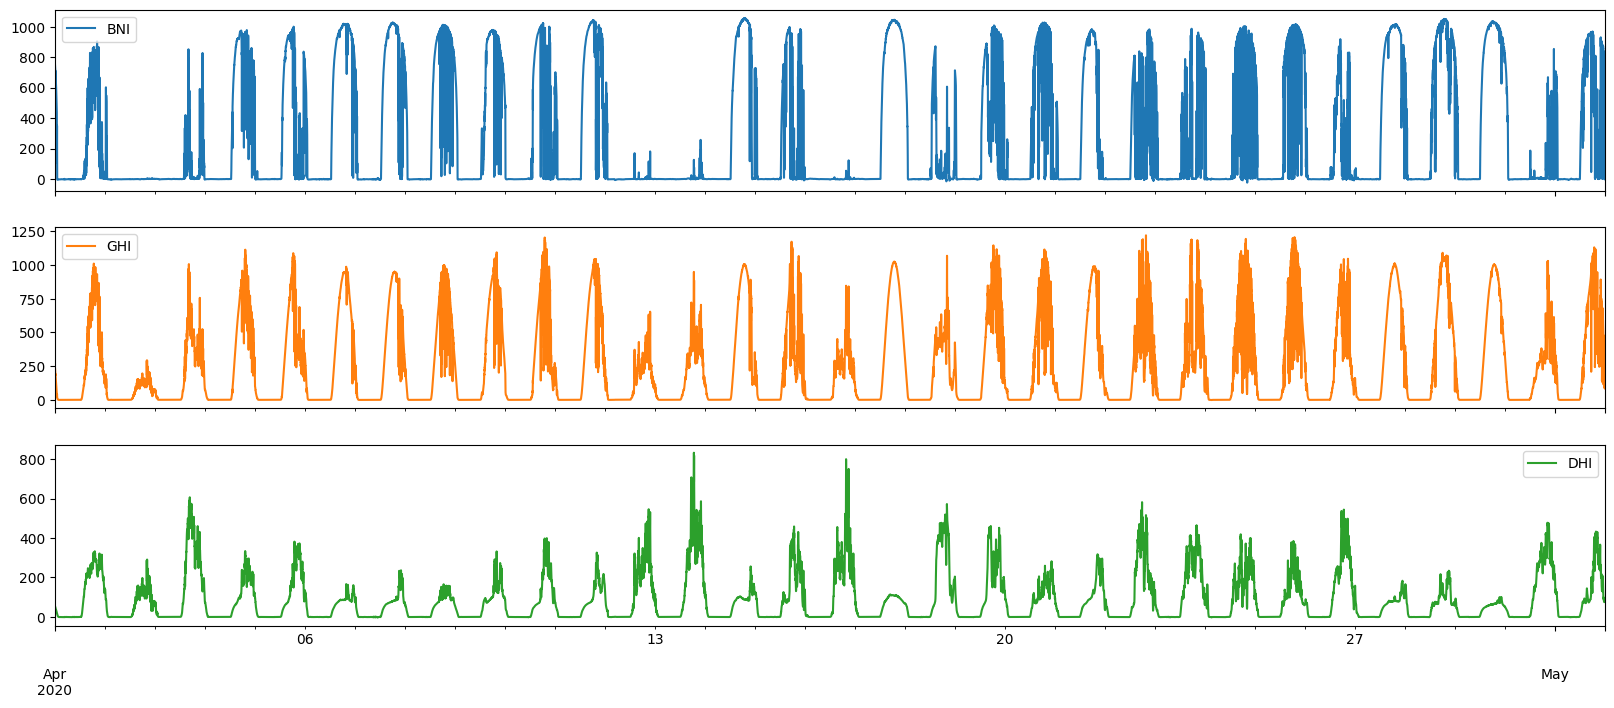

In [7]:
# Show one month of data
df["2020-04-01":"2020-05-01"].plot(figsize=(20, 8), subplots=True)

DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 00:01:00',
               '2020-01-01 00:02:00', '2020-01-01 00:03:00',
               '2020-01-01 00:04:00', '2020-01-01 00:05:00',
               '2020-01-01 00:06:00', '2020-01-01 00:07:00',
               '2020-01-01 00:08:00', '2020-01-01 00:09:00',
               ...
               '2021-02-28 23:50:00', '2021-02-28 23:51:00',
               '2021-02-28 23:52:00', '2021-02-28 23:53:00',
               '2021-02-28 23:54:00', '2021-02-28 23:55:00',
               '2021-02-28 23:56:00', '2021-02-28 23:57:00',
               '2021-02-28 23:58:00', '2021-02-28 23:59:00'],
              dtype='datetime64[ns]', length=612000, freq='T')


[09:57:59] INFO     -:-     QC: visual plot preparation

[09:57:59] INFO     -:-     plotting timeseries for GHI

[09:57:59] INFO     -:-     plotting timeseries for DNI

[09:57:59] INFO     -:-     plotting timeseries for DIF

[09:57:59] INFO     -:-     plotting heatmap timeseries for GHI

[09:58:00] INFO     -:-     plotting heatmap timeseries for DNI

[09:58:00] INFO     -:-     plotting heatmap timeseries for DIF

2022-11-30 09:58:01.382011: --> QC: BSRN 1C - GHI
2022-11-30 09:58:01.640163: --> QC: BSRN 1C - DNI
2022-11-30 09:58:01.900859: --> QC: BSRN 1C - DIF
2022-11-30 09:58:02.129191: --> QC: BSRN 2C 
2022-11-30 09:58:02.166568: --> QC: SERI-Kn 
2022-11-30 09:58:02.202549: --> QC: SERI-K 
2022-11-30 09:58:02.240911: --> QC: BSRN closure ymeas=f(yest)
2022-11-30 09:58:02.299620: --> QC: BSRN closure ratio=f(SZA)
2022-11-30 09:58:02.353727: --> QC: print general infos
2022-11-30 09:58:02.390862: --> QC: histograms of K, Kn & KT
2022-11-30 09:58:02.574158: --> QC: Shadow analysis (GHI)
2022-11-30 09:58:02.659609: --> QC: Shadow analysis (DNI)


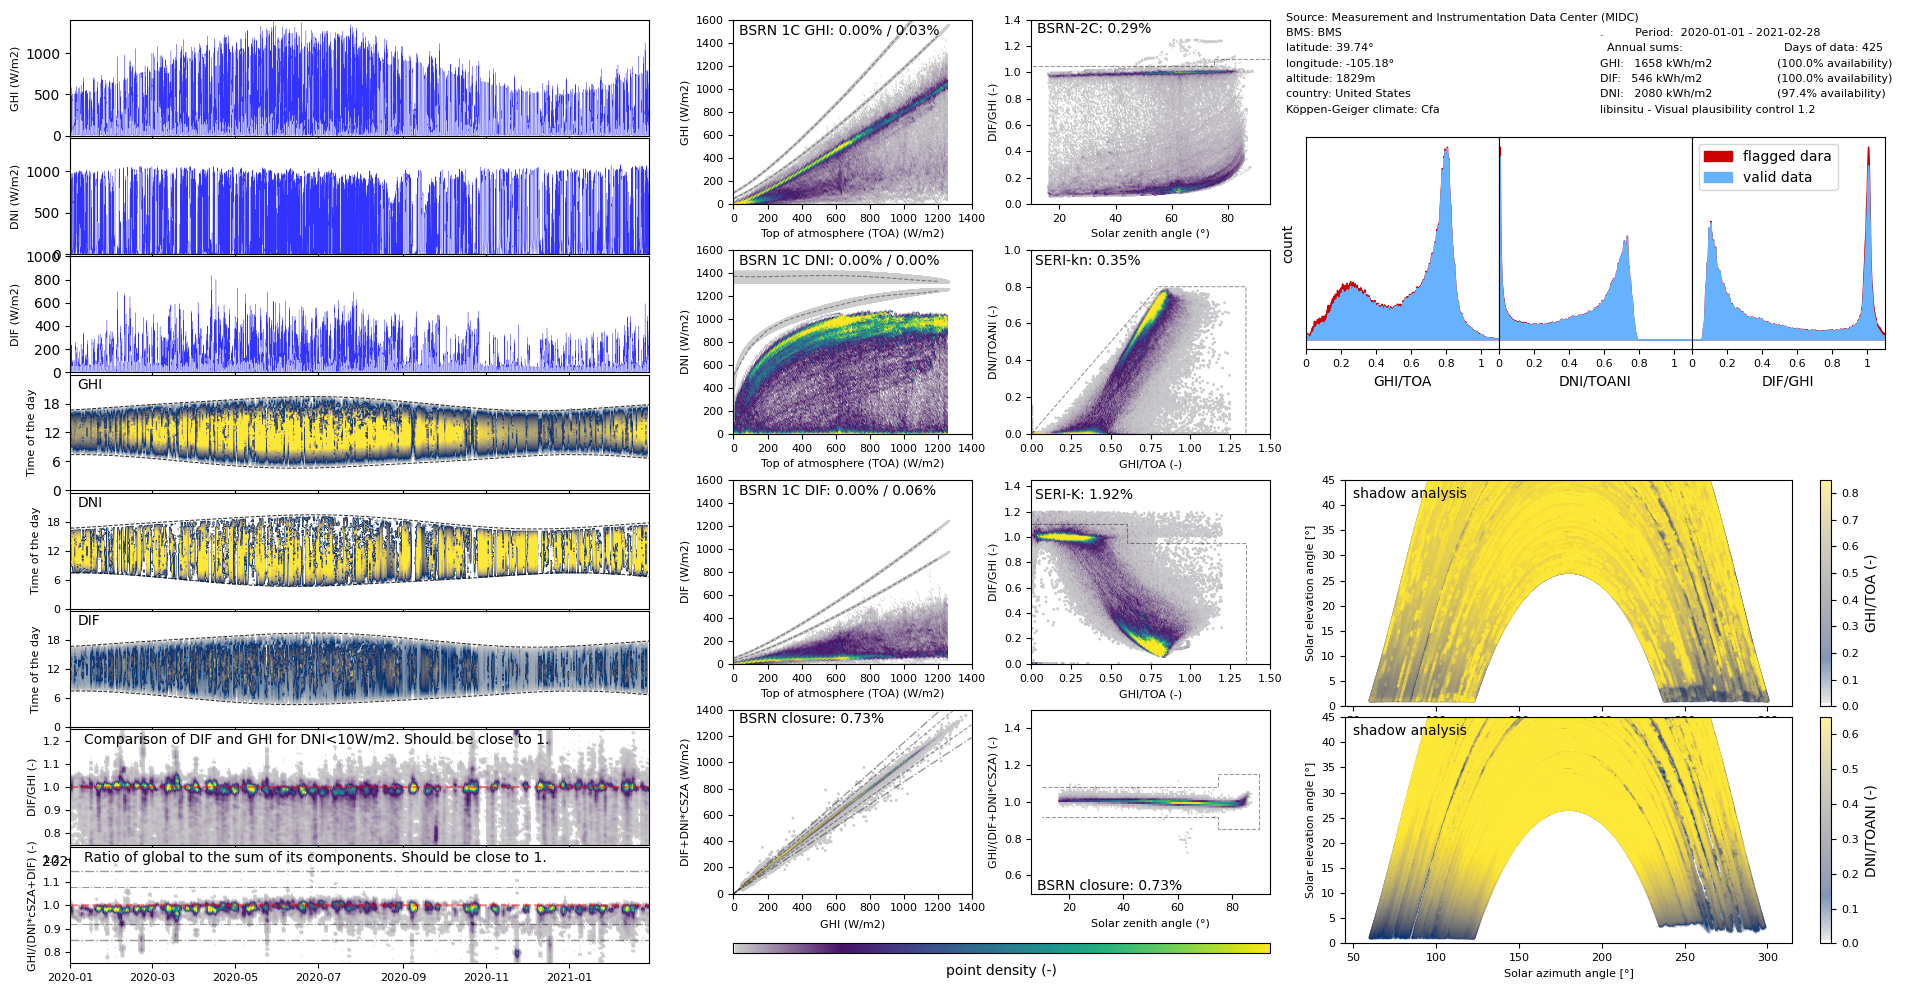

In [11]:
visual_qc(
    df,
    latitude=39.742,
    longitude=-105.18,
    elevation=1828.8)